# Opgave 3: Google PageRank algorithm and the worldwide web

Introduction PageRank
PageRank algorithm is the algorithm that Google uses/used to rank webpages for their search
engine. The algorithm is named after the Google founder Larry Page. This algorithm models
the odds that someone lands on a webpage by randomly clicking hyperlinks in webpages. We
can approximate the PageRank by simulating that process.

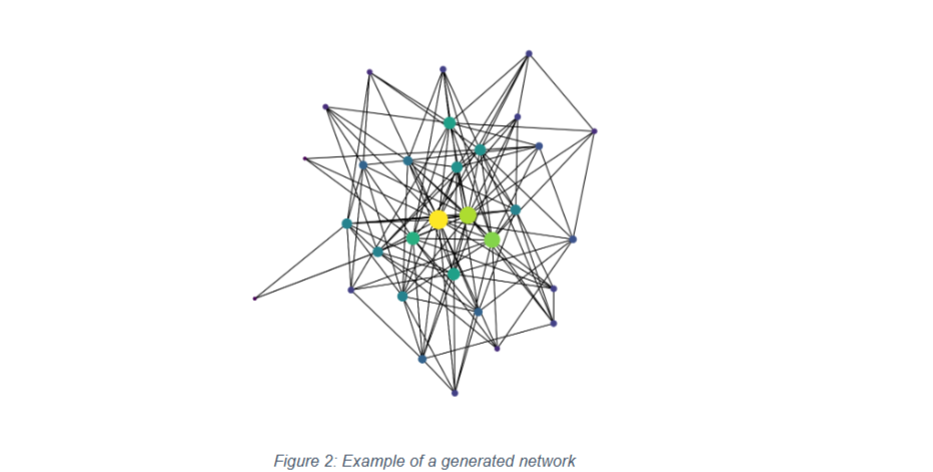 <br>
<br>
<br>
Let’s look at a small example: <br>
<br>
<br>
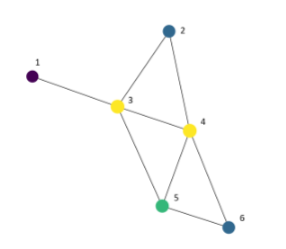

You are surfing on the web randomly and are currently on page 3 (node 3 in above graph).
With probability 𝛼, we go to a randomly chosen page that is linked to page 3. This means that
we randomly chose page 1, 2, 4 or 5, as those are all connected to page 3 (see the graph
again). All linked pages (1, 2, 4 and 5) have equal probability to be chosen. <br>
<br>
With probability (1 ― 𝛼) we go to any random page that is not connected to the page we are
currently visiting. In above example, where we are visiting page 3, this means that there is
(1 ― 𝛼) probability that we surf to page 6 (by typing in the URL of page 6 in the address bar).
For each page, we count the number of times we visited that page. In total, we visit 𝑇 number
of pages. The estimated PageRank of every page is the number of visits to that page divided
by 𝑇.

**Introduction Random Networks** <br>
In order to calculate the PageRank, we first need to have a graph that represents the world
wide web. To work with graphs, we use the package networkx. The network we are going to
make is based on the Barabasi-Albert algorithm.
We start with a star network that we can generate with networkx.star_graph(𝑘). This makes a
graph with 𝑘 nodes around 1 ‘hub’ (a center nodes that is connected to all the other nodes,
see below image where we used 𝑘 = 5). We often see this behaviour on the world wide web,
where multiple websites link to 1 website (for example Wikipedia or YouTube).

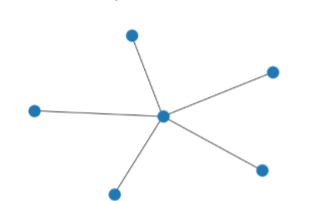 <br>
<br>
<br>
Next, someone creates a new webpage 𝑘 + 1 and links to 𝑀 already existing pages of the
star network with probability <br>
<br>
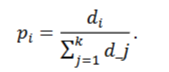

Here, 𝑝𝑖 is the probability that page 𝑘 + 1 links to page 𝑖. Furthermore 𝑑𝑖 is the number of
links page 𝑖 already has (this is often called the degree of 𝑖). This means that, the more links
a webpage has, the greater the probability that a new page will link to that page. <br>
<br>
_For example with 𝑘 = 5 and 𝑀 = 2: we have 5 pages and we add the 6th page. This 6th page
should connect to two other pages. We are given the following table_

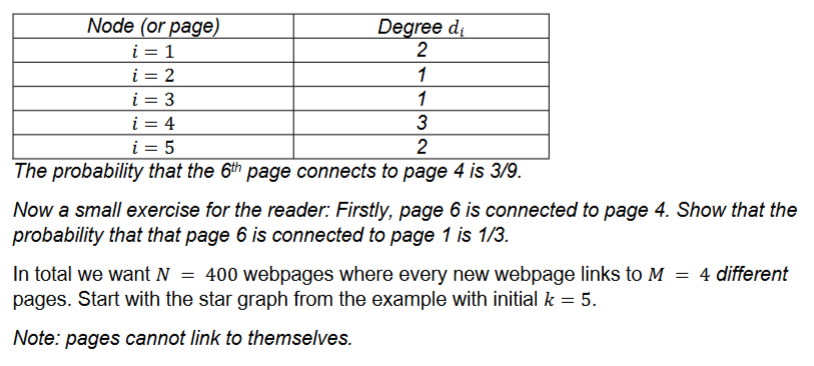

#### **Opgave 3.1**

Model a Barabasi-Albert network as described in the introduction. Calculate the estimated
PageRank on this network (from the simulations). Make a notebook where you visualise your
generated network and the distribution of the PageRank ‘probabilities’.
Things to think about:
1. Work in Github from the start (mandatory)
2. Break down the code into smaller functions. Give each person a task. In the
main.ipynb file, clearly describe the tasks and who is responsible for that task.
3. Create docstrings and type hints for your functions (mandatory). Add the name of the
person(s) that made the function in the docstring.
4. Generate your network with networkx (Python package), but you are not allowed to use
the graph generators (mandatory). First, make a small network to learn networkx and
then try to implement the algorithms. A good exercise would be to make the star graph
manually and visualise it.
5. We gave requirements for initial 𝑘, 𝑁 and 𝑀, but your code should work for general 𝑘, 𝑁
and 𝑀.

In [7]:
# Imports
import pandas as pd
import math as m
import networkx as nx
import scipy.stats as sp
import random
import matplotlib.pyplot as plt

In [ ]:
# Code

k = 5   # Aantal knopen in de ster (k = 5 betekent dat er 5 knopen zijn, inclusief de centrale knoop)

def generate_star_graph(): # Geneert een lege graaf en daarom moet de G van de nx graph niet in de definition staan. 
    # De G wordt in de hier aangemaakt en wordt doorgegeven aan de andere functies.
    """
    Genereert een stervormige graaf met k knopen.

    Een stergraaf (star graph) bestaat uit één centrale knoop (hier knoop 0) die verbonden is
    met alle andere knopen. De overige knopen hebben geen onderlinge verbindingen.

    Parameters:
        Geen parameters, de functie gebruikt de globale variabele k. Buiten de functie gedefinieerd, zodat deze makkelijk kan worden aangepast.

    Returns:
        G (networkx.Graph): Een nieuwe graaf (graph) met sterstructuur. 

    Codeur: Anny
    """
    
    # Maak een lege graaf
    G = nx.Graph()
    
    # Voeg k knopen toe, genummerd van 0 t/m k-1
    G.add_nodes_from(range(k))
    
    # Verbind de centrale knoop (0) met alle andere knopen
    for i in range(1, k):
        G.add_edge(0, i)
    
    return G

# De kansen functie toevoegen moeten we nog samen voor zitten morgen, echt het is een beetje lastig om te begrijpen.

def preferential_attachment(G, new_node, M): # definieert een functie om een nieuwe knoop toe te voegen, en deze te verbinden met M bestaande knopen op basis van hun graad.
    degrees = dict(G.degree()) # Slaat de graad van elke knoop op in een dictionary.
    targets = list(G.nodes()) # Slaat de bestaande knopen op in een lijst.
    chosen = set() # Een set om bij te houden welke knopen al gekozen zijn, zodat we ze niet opnieuw kunnen gebruiken
    
    while len(chosen) < M:
        # We gebruiken 'chosen', zodat we alleen nodes gebruiken die niet nog niet gekozen zijn.
        available = [node for node in targets if node not in chosen and node != new_node] # Dit voegt alle knopen die nog niet gekozen zijn en niet de nieuwe knoop zijn, toe aan de lijst van beschikbare knopen.
        weights = [degrees[node] for node in available] # 'weights' zijn de graden van de beschikbare knopen.
        total = sum(weights) # 'total' is de som van alle graden van de beschikbare knopen.
        probs = [w / total for w in weights] # 'probs' zijn de kansen van de beschikbare knopen, berekend door de graad van elke knoop te delen door de totale graad.
        
        selected = random.choices(available, weights=probs, k=1)[0] # Selecteert één knoop (k=1) uit de beschikbare knopen op basis van de kansen.
        chosen.add(selected) # Voegt de specifieke knoop toe aan de set van gekozen knopen.
    
    for target in chosen: # voor elke gekozen knoop maakt ie een verbinding tussen de nieuwe knoop en de gekozen knoop
        G.add_edge(new_node, target) # voegt een verbinding toe tussen de nieuwe knoop en elke gekozen knoop

#### **Opgave 3.2**

In exercise 3.1, we modelled an undirected network. This means that if node 𝑖 is linked to
node 𝑗, then node 𝑗 is automatically also linked to node 𝑖. However, this is not so realistic: the
probability that a new webpage links to Wikipedia is big, but the probability that Wikipedia
links to that new webpage is very small. We have to adjust our model so that it becomes a
directed model. <br>
<br>
A directed graph looks like this:

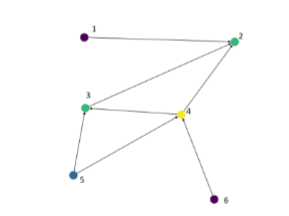

Now for example, as you can see from the way the arrow is positioned, page 3 links to page
2, but page 2 does not link to page 3. <br>
<br>
Let’s look at a more realistic example. We are going to look at a real network of Wikipedia,
namely the network of squirrel articles. <br> 
Why you might ask? The answer is contained in the
next image
<br>

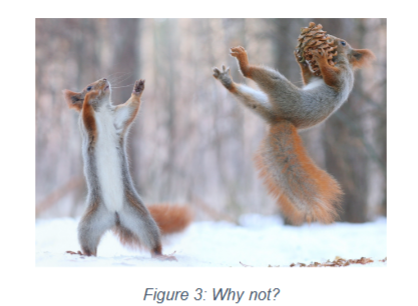 ik houd van eekhoorns

In ‘squirrel_edges.csv’, we see the connections between all the nodes. In the left column, we
can observe the source article, while in the right column, we can see the target article being
referenced.
Make a directed graph of this network (you are allowed to use nx.DiGraph() to create a
directed graph). Furthermore for the PageRank algorithm, we are no longer able to visit
arbitrary pages linked to our current page. Instead, we are restricted to accessing only the
pages that are directly linked. Modify your code such that it works for directed and undirected
graphs.
In the same notebook as exercise 3.1, calculate the PageRank of this network and visualise
the distribution of the PageRank ‘probabilities’. To calculate the PageRank of a network, you
can have a look at the pagerank_numpy function: <br>
<br>
Link 1: https://networkx.org/documentation/networkx-1.8/reference/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank_numpy.html <br>
<br>
Link 2: https://networkx.org/documentation/networkx-1.8/reference/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank_numpy.html <br>
<br>


## <span style="color:red;"> We mogen deze functie **niet** gebruiken voor opgave 3.1, alleen voor 3.2</span>



In [ ]:
# code


Het is belangrijk om te weten hoe deze functies werken voor ons examen, dus de volgende vragen kunnen gesteld worden:
1. Explain in your own words the process of collaborating in github.
2. Write a docstring and typehint for the following function

```python
def create_mandelbrot_image(diverging_indices):
# Convert the normalized diverging indices to a NumPy array
image = np.array(diverging_indices)
# Create a colormap for visualization
cmap = plt.cm.get_cmap('hot')
normalized_image = cmap(image)
return normalized_image
```

3. Explain in your own words what the following code does

```python
graph = nx.DiGraph()
graph.add_edges_from(edges)
```